# Course 5, Module 3, Lesson 2 Screencasts

## M3L2SC1: Boosting Performance with XGBoost and LightGBM

### Step 1: Setting up XGBoost

In [ ]:
# Install XGBoost
!pip install xgboost
!pip install seaborn

import xgboost as xgb
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the Titanic dataset
titanic = sns.load_dataset("titanic")
titanic = titanic.dropna(subset=['age', 'fare', 'sibsp', 'parch'])

# Select features and target
X = titanic[['age', 'fare', 'sibsp', 'parch']]
y = titanic['survived']

### Step 2: Training a Model with XGBoost

In [ ]:
# Prepare training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Load data into DMatrix
data = xgb.DMatrix(data=X_train, label=y_train)

# Train XGBoost model
param = {'max_depth': 3, 'eta': 0.1, 'objective': 'binary:logistic'}
model = xgb.train(param, data, num_boost_round=100)

### Visualizing XGBoost Predictions

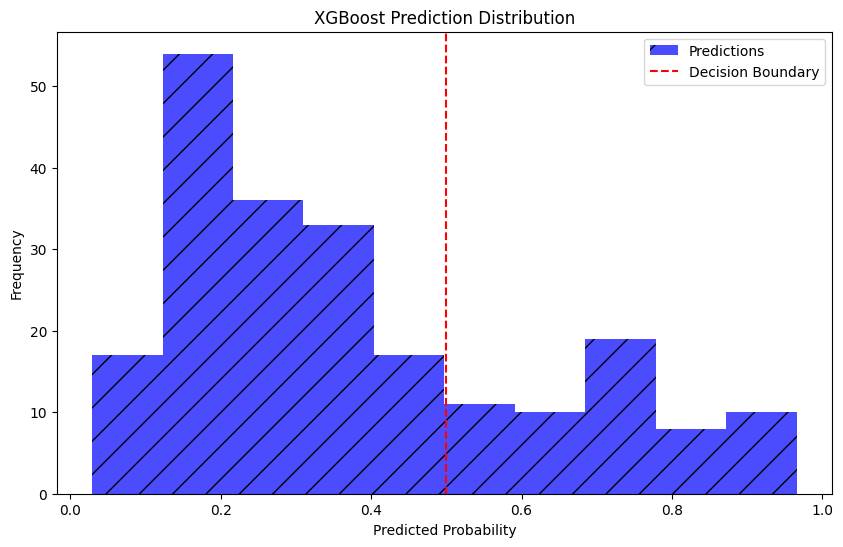

In [ ]:
# Predict with the model
test_data = xgb.DMatrix(data=X_test)
preds = model.predict(test_data)

# Visualize predictions
plt.figure(figsize=(10, 6))
plt.hist(preds, bins=10, alpha=0.7, color='blue', label='Predictions', hatch='/')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Boundary')
plt.title('XGBoost Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Step 3: Setting Up and Training with LightGBM

In [ ]:
# Install LightGBM
!pip install lightgbm

import lightgbm as lgb

# Prepare LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)

# Define model parameters
lgb_params = {'objective': 'binary', 'metric': 'binary_logloss'}

# Train LightGBM model
lgb_model = lgb.train(lgb_params, train_data)

[LightGBM] [Info] Number of positive: 201, number of negative: 298
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000311 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 169
[LightGBM] [Info] Number of data points in the train set: 499, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.402806 -> initscore=-0.393789
[LightGBM] [Info] Start training from score -0.393789
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


### Visualizing LightGBM Predictions

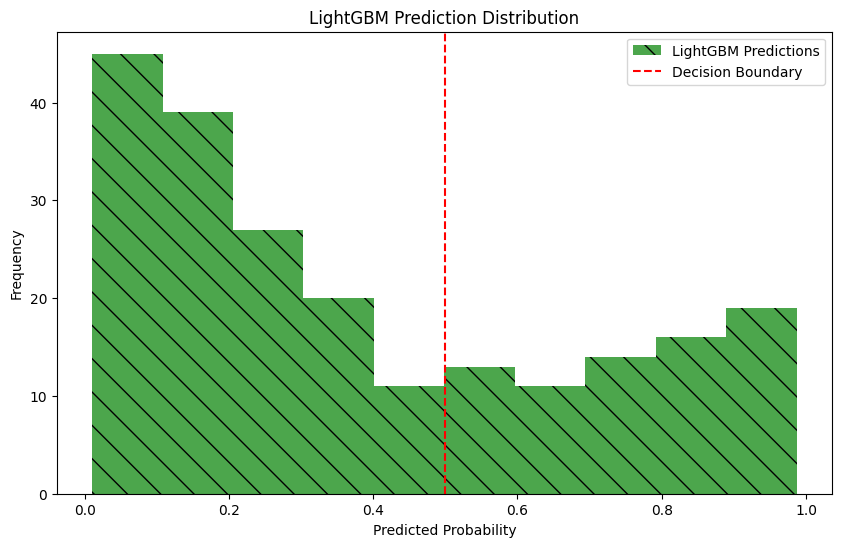

In [ ]:
# Predict with the model
lgb_preds = lgb_model.predict(X_test)

# Visualize predictions
plt.figure(figsize=(10, 6))
plt.hist(lgb_preds, bins=10, alpha=0.7, color='green', label='LightGBM Predictions', hatch='\\')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Boundary')
plt.title('LightGBM Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## M3L2SC2: Deep Learning for Vision and Text: CNNs and Transformers in Action

### Step 1: Define a CNN Model

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Create a simple CNN model
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn_model.summary()

# Load an example image
image = load_img('example_image.jpg', target_size=(64, 64))
image_data = img_to_array(image)
image_data = image_data.reshape((1, 64, 64, 3)) # Preparing the image to match input shape

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,922 (3.14 MB)

 Trainable params: 822,922 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

### Step 2: Initialize a BERT tokenizer and model

In [ ]:
from transformers import BertTokenizer, BertModel

# Initialize a BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
transformer_model = BertModel.from_pretrained('bert-base-uncased')

# Tokenize the input sentence
inputs = tokenizer("Deep learning is transformative!", return_tensors="pt")

# Obtain the outputs from the model
outputs = transformer_model(**inputs)
print(outputs.last_hidden_state.shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

torch.Size([1, 8, 768])


### Step 3: Merging CNNs and Transformers

In [ ]:
# Example of combining CNN and Transformer (conceptual code snippet)
image_features = cnn_model.predict(image_data)

# Convert the image feature vector to a single string
image_features_str = " ".join(map(str, image_features.flatten()))

# Tokenize as if it's text
inputs = tokenizer(image_features_str, return_tensors="pt")

# Get transformer outputs
outputs = transformer_model(**inputs)
print(outputs.last_hidden_state.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
torch.Size([1, 60, 768])


## M3L2SC3: Generative AI in Action: From Noise to Images with Diffusion Models

### Step 1: Setting Up Your Environment

In [ ]:
# Installing essential libraries
!pip install torch torchvision

### Step 2: Model Architecture

In [ ]:
import torch.nn as nn

class DiffusionModel(nn.Module):
    def __init__(self):
        super(DiffusionModel, self).__init__()
        # Define layers here
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.noise_remover = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        denoised = self.noise_remover(encoded)
        return self.decoder(denoised)

### Step 3: Training the Model

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# Example training data
train_images = torch.randn(100, 3, 64, 64)  # 100 random images
train_dataset = TensorDataset(train_images)
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

# Define the model, loss function, and optimizer
model = DiffusionModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def add_noise(images):
    noise = torch.randn_like(images) * 0.5
    return images + noise

def train_model(model, data_loader, epochs):
    for epoch in range(epochs):
        for i, (images,) in enumerate(data_loader):
            noisy_images = add_noise(images)
            outputs = model(noisy_images)
            loss = criterion(outputs, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f'Epoch {epoch}/{epochs}, Loss: {loss.item()}')

train_model(model, train_loader, epochs=5)

Epoch 0/5, Loss: 1.0807238817214966
Epoch 1/5, Loss: 0.999984085559845
Epoch 2/5, Loss: 0.9988227486610413
Epoch 3/5, Loss: 1.0069584846496582
Epoch 4/5, Loss: 1.0084725618362427


### Step 4: Visualizing and Evaluating

Min value: 1.3363131068569005e-20, Max value: 0.08354368805885315
Min value: 3.0415725160433196e-20, Max value: 0.07506909221410751
Min value: 4.362670104052576e-21, Max value: 0.07412531971931458


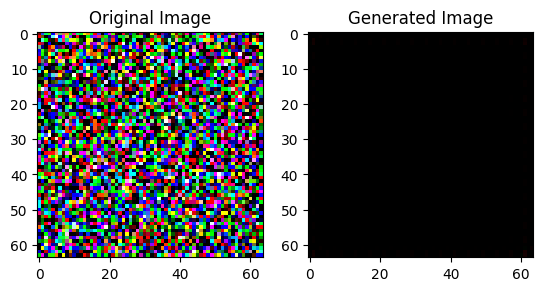

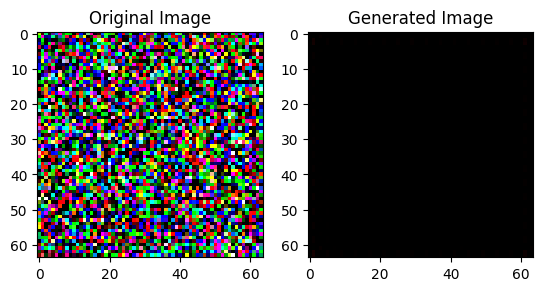

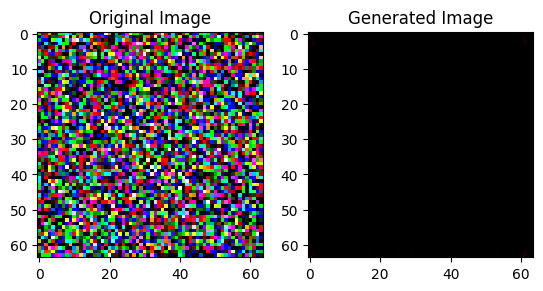

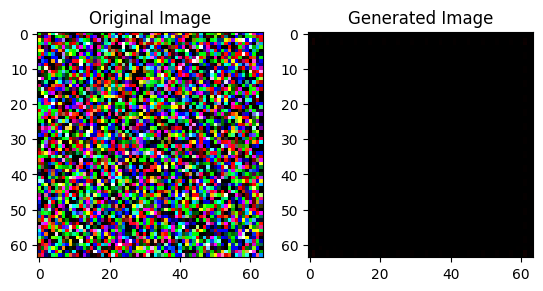

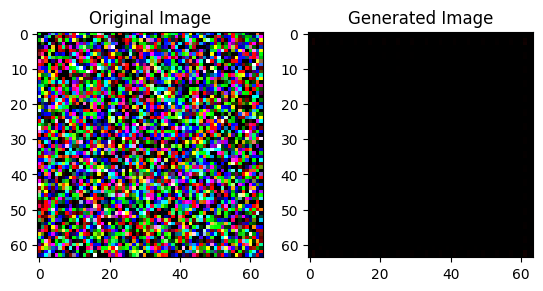

In [ ]:
import matplotlib.pyplot as plt

def display_comparison(original, generated):
    original = original.permute(1, 2, 0).numpy()
    generated = generated.permute(1, 2, 0).detach().numpy()

    # Clip the values to the valid range [0, 1] for displaying
    original = original.clip(0, 1)
    generated = generated.clip(0, 1)

    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(original)
    axes[0].set_title("Original Image")
    axes[1].imshow(generated)
    axes[1].set_title("Generated Image")
    plt.show()

# Verify model output
def verify_model_output(model, test_loader):
    for i, (images,) in enumerate(test_loader):
        noisy_images = add_noise(images)
        outputs = model(noisy_images)
        print(f"Min value: {outputs.min().item()}, Max value: {outputs.max().item()}")

# Example test data
test_images = torch.randn(5, 3, 64, 64)  # 5 random images
test_dataset = TensorDataset(test_images)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

def evaluate_model(model, test_loader):
    for i, (images,) in enumerate(test_loader):
        noisy_images = add_noise(images)
        outputs = model(noisy_images)
        for j in range(images.size(0)):
            display_comparison(images[j], outputs[j])

verify_model_output(model, test_loader)
evaluate_model(model, test_loader)